In [1]:
#Import all the relevant libraries
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Descriptors
from rdkit.Chem import AllChem
from rdkit import DataStructs
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Import the dataset
df = pd.read_csv("../data_process/processed_data/processed_data.csv")
print(df.shape)
df.info()
print(df.head(10))



(110355, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110355 entries, 0 to 110354
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   SMILES     110355 non-null  object 
 1   MP         108399 non-null  float64
 2   Type       110355 non-null  object 
 3   exp MP     1956 non-null    float64
 4   GNN1       1956 non-null    float64
 5   GNN2       1956 non-null    float64
 6   GNN3       1956 non-null    float64
 7   GNN4       1956 non-null    float64
 8   GNN5       1956 non-null    float64
 9   GNN6       1956 non-null    float64
 10  GNN7       1956 non-null    float64
 11  GNN8       1956 non-null    float64
 12  GNN9       1956 non-null    float64
 13  GNN10      1956 non-null    float64
 14  Consensus  1956 non-null    float64
 15  SD         1956 non-null    float64
 16  Mpexp      0 non-null       float64
dtypes: float64(15), object(2)
memory usage: 14.3+ MB
                                           

In [3]:
# Check which coloumns hae NA values
print(df.isna().sum())


SMILES            0
MP             1956
Type              0
exp MP       108399
GNN1         108399
GNN2         108399
GNN3         108399
GNN4         108399
GNN5         108399
GNN6         108399
GNN7         108399
GNN8         108399
GNN9         108399
GNN10        108399
Consensus    108399
SD           108399
Mpexp        110355
dtype: int64


In [4]:
print(len(df['SMILES']))

110355


In [5]:
def molecular_weight(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Descriptors.MolWt(mol)
        else:
            return None
    except:
        return None 

# Apply the function to your DataFrame and add a new column
df['MolecularWeight'] = df['SMILES'].apply(molecular_weight)

[10:50:13] Explicit valence for atom # 5 N, 4, is greater than permitted
[10:50:13] Explicit valence for atom # 3 O, 3, is greater than permitted
[10:50:13] Explicit valence for atom # 3 O, 3, is greater than permitted
[10:50:13] Explicit valence for atom # 3 O, 3, is greater than permitted
[10:50:13] Explicit valence for atom # 3 O, 3, is greater than permitted
[10:50:13] Explicit valence for atom # 5 N, 4, is greater than permitted
[10:50:13] Explicit valence for atom # 3 O, 3, is greater than permitted
[10:50:14] Explicit valence for atom # 1 O, 3, is greater than permitted
[10:50:14] Explicit valence for atom # 1 O, 3, is greater than permitted
[10:50:14] Explicit valence for atom # 4 C, 5, is greater than permitted
[10:50:14] Explicit valence for atom # 4 C, 5, is greater than permitted
[10:50:14] Explicit valence for atom # 1 O, 3, is greater than permitted
[10:50:14] Explicit valence for atom # 1 O, 3, is greater than permitted
[10:50:14] Explicit valence for atom # 1 O, 3, is g

In [6]:
MW_yes = df['MolecularWeight'].notna().sum()
MW_no = df['MolecularWeight'].isna().sum()
print(MW_yes, MW_no, len(df))


110322 33 110355


In [7]:
view_df_no_MW = df[df['MolecularWeight'].isna()]
print(len(view_df_no_MW))
view_df_no_MW

33


,SMILES,MP,Type,exp MP,GNN1,GNN2,GNN3,GNN4,GNN5,GNN6,GNN7,GNN8,GNN9,GNN10,Consensus,SD,Mpexp,MolecularWeight
36549,[2H]N=C(O[2H])[NH]([2H])[2H],136.0,train_with_data_augmentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36550,[2H]N=C([OH][2H])N([2H])[2H],136.0,train_with_data_augmentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36551,[2H]N=C([OH][2H])[NH]([2H])[2H],136.0,train_with_data_augmentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36552,[2H]NC(=O[2H])N([2H])[2H],136.0,train_with_data_augmentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36553,[2H]NC(=O[2H])[NH]([2H])[2H],136.0,train_with_data_augmentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36554,[2H]NC(O[2H])=N([2H])[2H],136.0,train_with_data_augmentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
36555,[2H]NC([OH][2H])=N([2H])[2H],136.0,train_with_data_augmentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42182,[2H]O=C(O)C([2H])([2H])[2H],15.5,train_with_data_augmentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42183,[2H]O=C(O)[CH]([2H])([2H])[2H],15.5,train_with_data_augmentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
42184,[2H]OC(=O)[CH]([2H])([2H])[2H],15.5,train_with_data_augmentation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


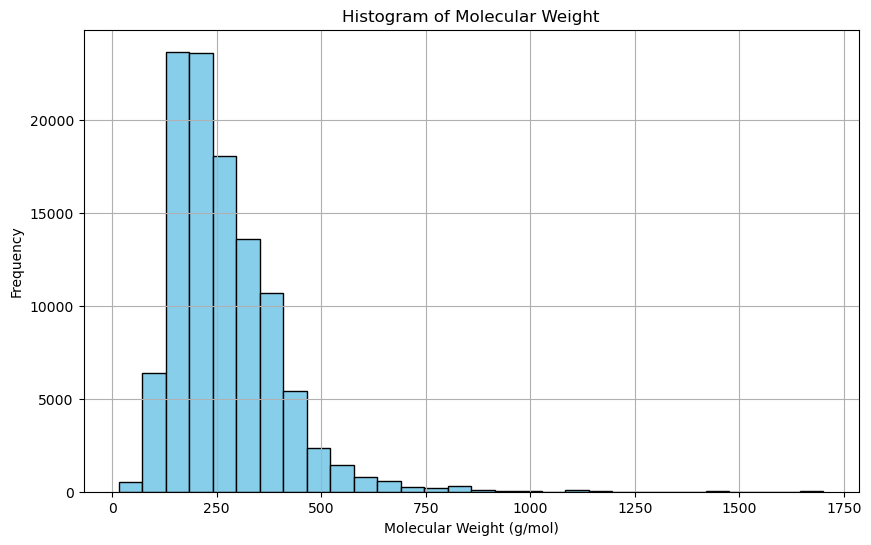

Index(['SMILES', 'MP', 'Type', 'exp MP', 'GNN1', 'GNN2', 'GNN3', 'GNN4',
       'GNN5', 'GNN6', 'GNN7', 'GNN8', 'GNN9', 'GNN10', 'Consensus', 'SD',
       'Mpexp', 'MolecularWeight'],
      dtype='object')
108366


In [8]:
#Filter out the na values for mw and mp
mw_valid_1 = df[df['MolecularWeight'].notna() & df['MP'].notna()]

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(mw_valid_1['MolecularWeight'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of Molecular Weight')
plt.xlabel('Molecular Weight (g/mol)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print(mw_valid_1.columns)
print(len(mw_valid_1))


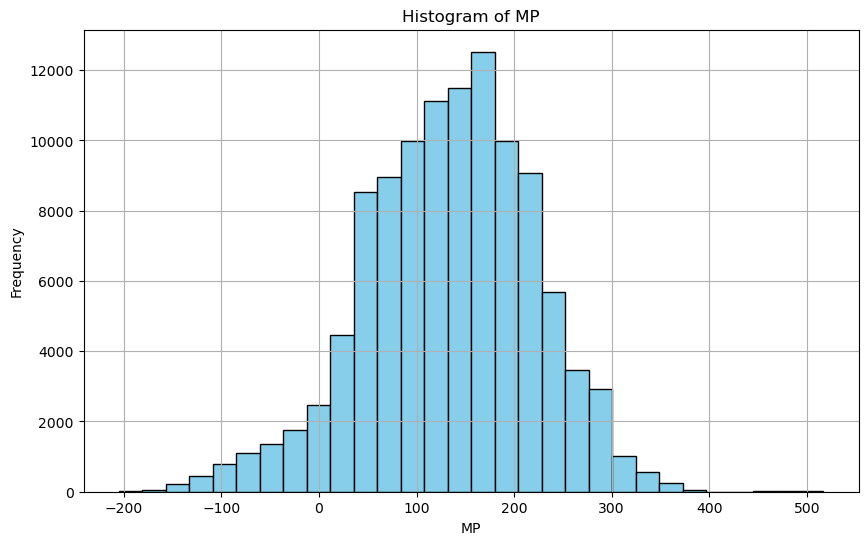

Index(['SMILES', 'MP', 'Type', 'exp MP', 'GNN1', 'GNN2', 'GNN3', 'GNN4',
       'GNN5', 'GNN6', 'GNN7', 'GNN8', 'GNN9', 'GNN10', 'Consensus', 'SD',
       'Mpexp', 'MolecularWeight'],
      dtype='object')
108366


In [9]:
#Filter out the na values for mw and mp
mw_valid_1 = df[df['MolecularWeight'].notna() & df['MP'].notna()]

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(mw_valid_1['MP'], bins=30, color='skyblue', edgecolor='black')
plt.title('Histogram of MP')
plt.xlabel('MP')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print(mw_valid_1.columns)
print(len(mw_valid_1))


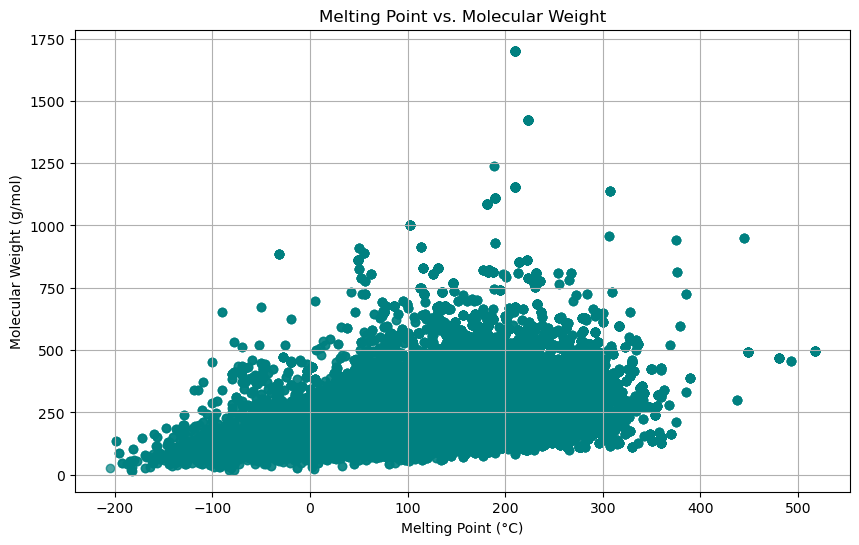

In [10]:


# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(mw_valid_1['MP'], mw_valid_1['MolecularWeight'], alpha=0.7, color='teal')

# Axis labels and title
plt.title('Melting Point vs. Molecular Weight')
plt.xlabel('Melting Point (°C)')
plt.ylabel('Molecular Weight (g/mol)')
plt.grid(True)
plt.show()

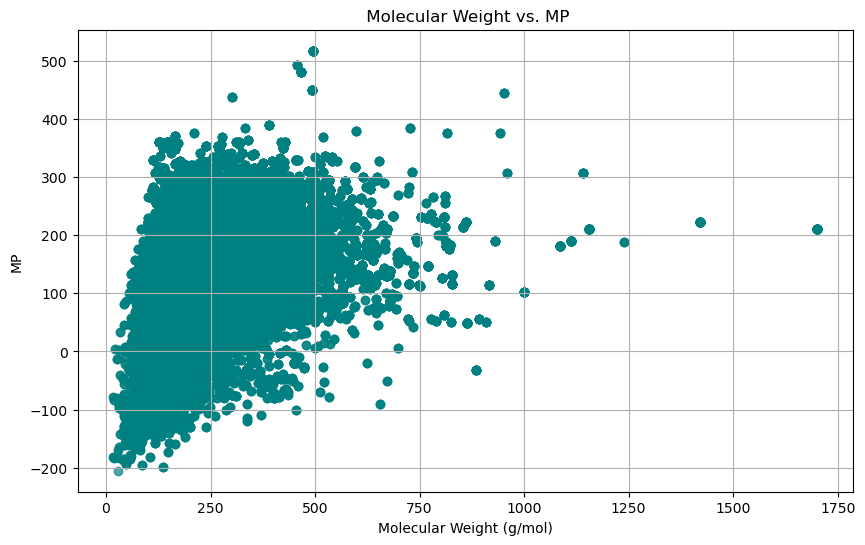

In [11]:
# Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter( mw_valid_1['MolecularWeight'], mw_valid_1['MP'], alpha=0.7, color='teal')

# Axis labels and title
plt.title(' Molecular Weight vs. MP')
plt.xlabel('Molecular Weight (g/mol)')
plt.ylabel('MP')
plt.grid(True)
plt.show()

Text(0, 0.5, 'MP')

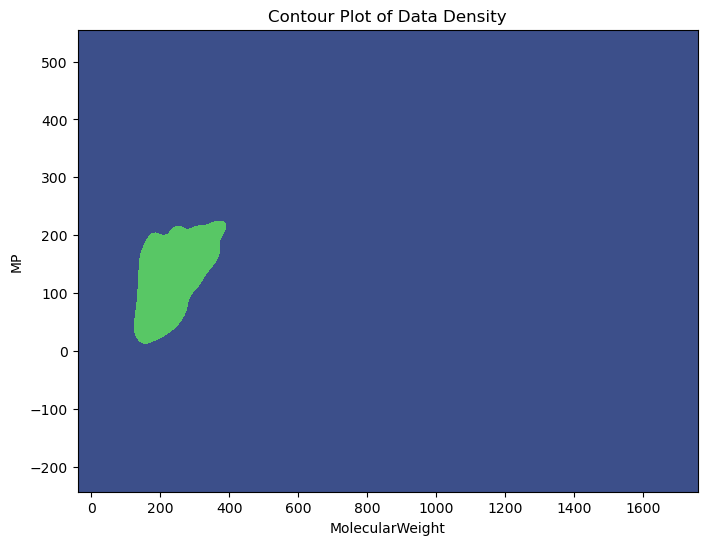

In [12]:
import seaborn as sns
x = mw_valid_1['MolecularWeight']
y = mw_valid_1['MP']

plt.figure(figsize=(8, 6)) # Optional: set figure size
sns.kdeplot(x=x, y=y, fill=True, cmap='viridis', thresh=0, levels=3)

plt.title('Contour Plot of Data Density')
plt.xlabel('MolecularWeight')
plt.ylabel('MP')


In [13]:
print(mw_valid_1.isna().sum())


SMILES                  0
MP                      0
Type                    0
exp MP             108366
GNN1               108366
GNN2               108366
GNN3               108366
GNN4               108366
GNN5               108366
GNN6               108366
GNN7               108366
GNN8               108366
GNN9               108366
GNN10              108366
Consensus          108366
SD                 108366
Mpexp              108366
MolecularWeight         0
dtype: int64


In [14]:
correlation_matrix = mw_valid_1[['MolecularWeight', 'MP']].corr()
pearson_r_pandas = correlation_matrix.loc['MolecularWeight', 'MP']
print(pearson_r_pandas)


0.3811358136763979


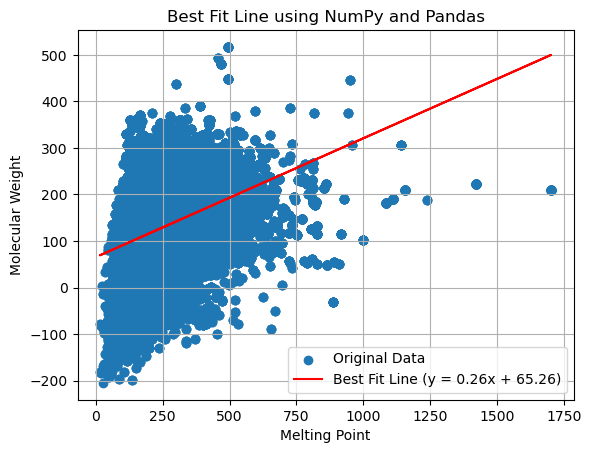

In [15]:
#Extract x and y values 
x = mw_valid_1['MolecularWeight'].values
y = mw_valid_1['MP'].values 

slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

# Plotting (optional)
plt.scatter(x, y, label='Original Data')
plt.plot(x, y_pred, color='red', label=f'Best Fit Line (y = {slope:.2f}x + {intercept:.2f})')
plt.xlabel('Melting Point')
plt.ylabel('Molecular Weight')
plt.title('Best Fit Line using NumPy and Pandas')
plt.legend()
plt.grid(True)
plt.show()